# Práctica 6.1: Introducción a aprendizaje estadístico

Clase basada en el libro "Introduction to Stadistical Learning with Python", disponible en https://www.statlearning.com/

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Para MLS
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D
#Para no parametricos
from scipy.interpolate import SmoothBivariateSpline

>[Práctica 6.1: Introducción a aprendizaje estadístico](#scrollTo=146KbRyU9ffy)

>>[Aprendizaje estadístico](#scrollTo=7S0PgxqQEVQY)

>>>[Definición y alcances](#scrollTo=wVTXRQz4_Okn)

>>>[Línea histórica](#scrollTo=PTqH4h6wEZxd)

>>[¿Qué nos interesa predecir?](#scrollTo=WxsBeu5RD0AS)

>>[Razones para estimar $f$](#scrollTo=E0-4J99_O64x)

>>>[Predicción](#scrollTo=-8riXLq8PDVx)

>>>[Inferencia](#scrollTo=etqebRo0PFNq)

>>>[Un ejemplo aplicado a Properati](#scrollTo=IKTwo3T2QCAA)

>>[¿Cómo estimamos nuestra función predictora?](#scrollTo=9lAPLMxVD4uE)

>>>[Modelos paramétricos](#scrollTo=6Ssg_I1kYi5x)

>>>[Modelos no paramétricos](#scrollTo=P4SdpVeTYmaX)

>>[Trade-Off entre performance e interpretabilidad](#scrollTo=bF-pb3O-D-Av)

>>[Supervisado vs no supervisado](#scrollTo=sQp14KNtEDxm)

>>[Regresión vs Clasificación](#scrollTo=ee3jlpH1EIhz)

>>[Evaluación de la performance de un modelo](#scrollTo=qkH-Fb4v5IJD)

>>>[Midiendo la bondad de ajuste](#scrollTo=k5s27aHs6yvh)

>>>>[$MSE_{train}$ vs. $MSE_{test}$](#scrollTo=3eCZj1SD2ryR)

>>>>[Relación entre $MSE_{train}$ y $MSE_{test}$. Overfitting](#scrollTo=9ADIDKlp7n7o)

>>>[Trade-off sesgo-varianza](#scrollTo=cIgBrO7-9wvI)

>>>[Composición del error](#scrollTo=P0_dgA6q8epI)

>>>>[¿A qué nos referimos con la varianza y el bias de un método?](#scrollTo=ThN5x_Es9G80)

>>>[Impacto de trade-off sesgo-varianza en el MSE](#scrollTo=2QoaRIt__v99)

>>>>[Resumen del trade-off sesgo-varianza](#scrollTo=WdSMHLhDErHI)

>>>[Problema de clasificación](#scrollTo=B9CcN2nM_i6u)

>>>>[El clasificador de Bayes](#scrollTo=owTzbpvYaIUk)

>>>>[K-Nearest Neighbors (KNN)](#scrollTo=yLL-Ge-edJBK)

>>[Librerías nuevas](#scrollTo=OWd9CzBgEO3j)



## Aprendizaje estadístico

### Definición y alcances

El aprendizaje estadístico se refiere a un amplio conjunto de herramientas para comprender datos. Hemos visto distintos ejemplos de datasets ya a lo largo de la materia y llevándolo hacia la segunda parte de la materia en función de lo que buscáramos analizar

Tenemos dos grandes variantes que reforzaremos las siguientes clases de forma particular

- En el **aprendizaje supervisado**, se construyen modelos estadísticos para predecir o estimar una variable de salida a partir de una o más variables de entrada. Este tipo de problema aparece en campos como los negocios, la medicina, políticas públicas, etc.

- En el **aprendizaje no supervisado**, se trabaja solo con variables de entrada, sin una salida que supervisar. Aún así, podemos descubrir relaciones y estructuras en los datos.



---



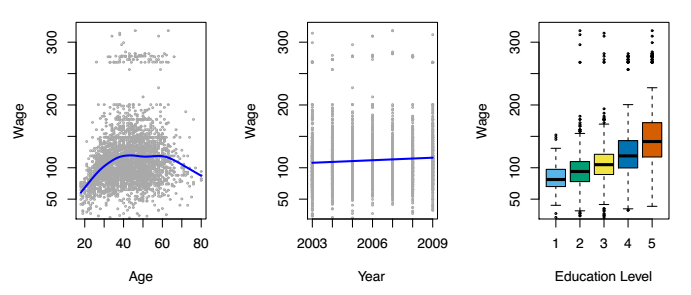

*Información de salarios para una encuesta a varones (EEUU) en función de 3 variables: la edad, el año de la muestra y el nivel de educación. Un modelo de **aprendizaje supervisado del salario** combinará las 3 varaibles de determinada forma (notar que con la edad debemos poder capturar una relación no lineal)*

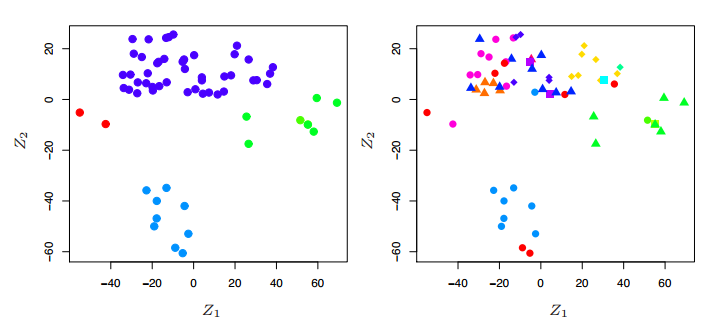

*Representación de las dos primeras componentes principales de NCI60 (60 líneas celulares de cáncer). Representado en colores vemos a derecha los 14 tipos de cáncer del set de datos, a izquierda una propuesta de clusterización en 4  grupos. En un problema de **aprendizaje no supervisado** pasamos a poder agrupar en grupos distintos genes en función de sus 6830 variables*

### Línea histórica



*   **Siglo XIX (1805-1809)**: método de los mínimos cuadrados (base de la regresión lineal), por Legendre y Gauss, aplicado a astronomía y geodesia [Least Squares](https://en.wikipedia.org/wiki/Least_squares)
*   **1936**: Fisher propone análisis discrinante lineal para predecir variables cualitativas (por ejemplo, subas o bajas del mercado) [Linear discriminant analysis](https://en.wikipedia.org/wiki/Linear_discriminant_analysis)
*   **Década del 40'**: regresión logística como alternativa para predecir variables categóricas.
*   **Comienzos 70'**: aparecen modelos lineales genralizados (GLM), que engloban regresión lineal y logística.
*   **Finales 70'**: avanza la estadística, pero el cuello de botella terminan siendo las limitaciones computacionales para procesar grandes volúmenes de datos.
*  **Años 80'**: con mejora de hardware, se implementan métodos no lineales.
*   **Mitad de la década del 80'**: se introducen los árboles de clasificación y regresión. Aparece la validación cruzada como técnica. Aparición de los modelos aditivos generalizados (GAM).
*   **De los 90' al presente**: avances en redes neuronales artificiales. Bagging y boosting como métodos de ensamble. Algoritmos de árboles tipo Random Forest (2001)




## ¿Qué nos interesa predecir?

Importamos a continuación un dataset de ventas de un producto en 200 mercados distintos, con los valores de presupuesto asignados a cada segmento (TV, diarios, television).

El cliente nos contacta para mejorar las ventas de este producto, a sabiendas que:
- No puedo incrementar ventas de un producto de forma directa.
- Solo tiene control de los presupuestos a destinar en cada caso (TV, diarios y radio).

Nos interesa entonces entregarle al cliente una instrucción de cómo ajustar su presupuesto por sector para incrementar ventas a nivel global.

In [ ]:
!gdown 1-Y70jMOVqbpI-dQgoTvHLjca8-q2h7hJ
df = pd.read_csv('advertising.csv')

Downloading...
From: https://drive.google.com/uc?id=1-Y70jMOVqbpI-dQgoTvHLjca8-q2h7hJ
To: /content/advertising.csv
100% 4.06k/4.06k [00:00<00:00, 12.9MB/s]


In [ ]:
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


Por lo tanto, siendo

$X_1, X_2, X_3$: las variables independientes (TV, radio, diarios)  
$Y$: variable dependiente (ventas)

Nos interesa poder llegar a una función desconocida que dependerá de las 3 variables del problema y que tendrá un error asociado, denominado **término de error aleatorio**

$$
Y = f(X) + \epsilon
$$

$f$ representa la información sistémica nos brinda X. El aprendizaje estadístico refiere a todo lo que hagamos por estimar `f` de la mejor manera y de las herramientas para evaluar los valores obtenidos. En el gráfico debajo vemos modelos simples de cuadrados mínimos para estimar ventas en función de cada variable desglosada.

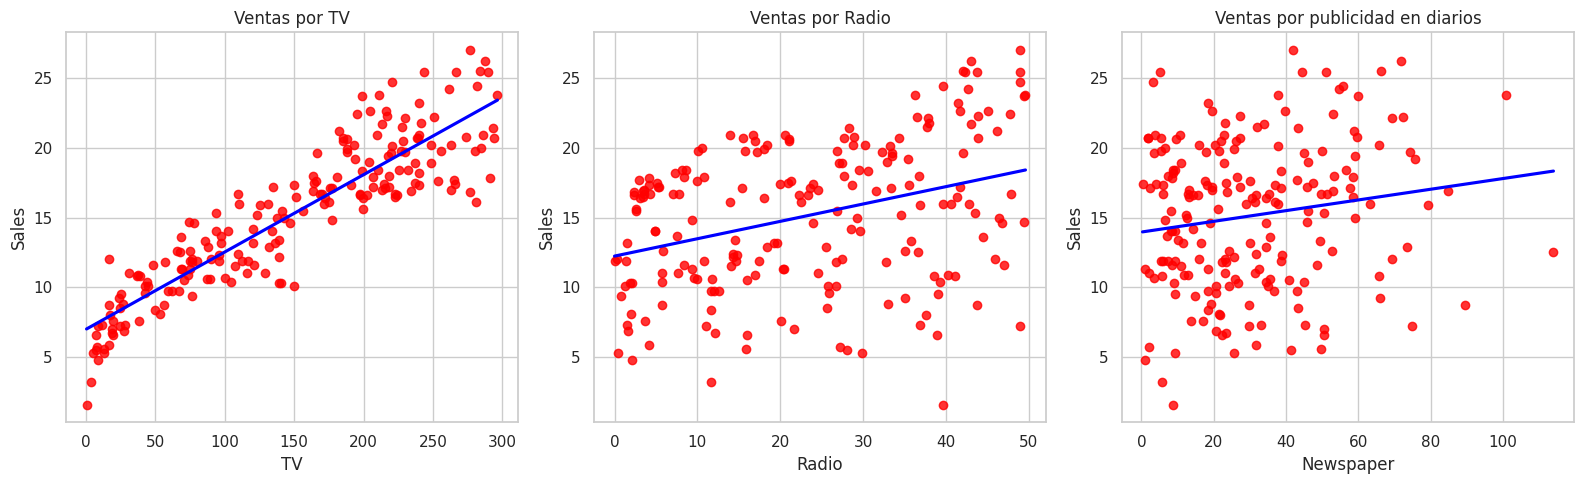

In [ ]:
# Creamos un gráfico de las 3 utilizando seaborn con regplot, que crea un modelo de regresión lineal en cada caso
# Estilo de seaborn
sns.set(style="whitegrid")

# Crear el gráfico con 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# TV vs Sales
sns.regplot(x='TV', y='Sales', data=df, ax=axs[0], scatter_kws={'color': 'red'}, line_kws={'color': 'blue'},ci=None)
axs[0].set_title('Ventas por TV')

# Radio vs Sales
sns.regplot(x='Radio', y='Sales', data=df, ax=axs[1], scatter_kws={'color': 'red'}, line_kws={'color': 'blue'},ci=None)
axs[1].set_title('Ventas por Radio')

# Newspaper vs Sales
sns.regplot(x='Newspaper', y='Sales', data=df, ax=axs[2], scatter_kws={'color': 'red'}, line_kws={'color': 'blue'},ci=None)
axs[2].set_title('Ventas por publicidad en diarios')

plt.tight_layout()
plt.show()

## Razones para estimar $f$

Hay dos razones principales para estimar una función respuesta: la predicción y la inferencia. No siempre van por caminos separados y en muchos casos tendremos una combinación de ambas

### Predicción

Tenemos un input $X$ sencillo de obtener pero una respuesta $Y$ que no lo es.

En ese caso, predecimos $Y$ como $\hat{Y} = \hat{f}(X)$, donde $\hat{f}(X)$ es un estimador de $f$ y $\hat{Y}$ es la variable predicha.

Cuando el enfoque principal es la predicción, la forma exacta de $f$ no interesa tanto ya que importa el valor predicho de $f$, y puede tratarse a $\hat{f}(X)$ como una *caja negra*

La precisión de la predicción depende del error **reducible** y del **irreducible**:

- **Error reducible**: Este error se puede disminuir aplicando la técnica de aprendizaje estadístico más adecuada para estimar $f$. Hace a la técnica utilizada su reducción.
- **Error irreducible**: Error debido a la variabilidad en $\epsilon$, la cual no puede predecirse a partir de $X$. Esto puede deberse a que no se incluyen otros predictores significativos y/o a variaciones no medibles. Sin importar lo bien que estimemos $\hat{f}(X)$, no podemos reducir el error introducido por $\epsilon$

Esto puede expresarse matemáticamente dividiendo el valor esperado del cuadrado de la diferencia entre el valor observado y el predicho de $Y$, es decir, $E[(Y - \hat{Y})^2]$, en:

$$
E[(Y - \hat{Y})^2] = \underbrace{[f(X) - \hat{f}(X)]^2}_{\text{Reducible}} + \underbrace{\text{Var}(\epsilon)}_{\text{Irreducible}}
$$

Donde el segundo término representa la varianza del término de error $\epsilon$.

**El propósito que perseguiremos en la materia es buscar reducir el error reducible. El irreproducible siempre será una frontera superior en la precisión de nuestras predicciones, y es desconocida**


### Inferencia

Se basa en entender el modo en que $Y$ es afectada por cambios en $X_1,..,X_p$. No necesariamente buscamos hacer predicciones de Y, pero sí queremos conocer la relación entre $X$ e $Y$ o encontrar cómo es esa función. No buscamos tener una caja negra o desentendernos de $f$ ya que precisamos conocerla.

Preguntas usuales en un problema de inferencia

- #### ¿Qué predictores de $X$ están asociados a la respuesta?

Dependiendo de la aplicación, puede ser muy eficaz buscar aquellas variables predicotras que sean realmente importantes en la asociación con $Y$.

- #### ¿Relación de la respuesta con cada predictor?

Vinculado a lo visto con el grado de asociación lineal, ¿cómo responde $Y$ para cada variable predictora? Dependiendo de la complejidad de $f$, el grado de asociación también podrá depender de valores que tomen otras variables predictoras.

- #### ¿Se puede reducir a una ecuación lineal la relación entre $Y$ y cada predictor?

La relación real entre variables no siempre puede resumirse a un modelo líneal. Es algo que se suele tomar de partida pero no siempre se cumple

### Un ejemplo aplicado a Properati

Tenemos un dataset con muchas variables asociadas a distintos tipos de propiedades.



*   ¿Cuánto más cuesta un departamento 2 ambientes si tiene un balcón?
*   ¿Cuánto más cara sale una propiedad si está orientada al norte?

Son problemas de inferencia.

*   ¿Este departamento está subvaluado o sobrevalorado?

Es un problema de predicción

La respuesta a cada una de esas preguntas tendrá asociado un método distinto para estimar $f$ y que se considere apropiado. La inferencia está atada a tener modelos interpretables. Un modelo sumamente complejo no ayuda en esos problemas



## ¿Cómo estimamos nuestra función predictora?

Llamamos set de entrenamiento(***training data***): observaciones que usaremos para entrenar y poder estimar $f$. Esto es aplicable a cualquier método que usaremos.

Nuestros datos de entrenamiento se componen entonces:

$${(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)}$$

donde:

$$x_i = (x_{i1}, x_{i2}, \dots, x_{ip})^T$$

es un vector columna con $p$ características (o variables predictoras) para la observación $i$.

**Objetivo**:aplicar un método de aprendizaje estadístico a los datos de entrenamiento para estimar la función desconocida $f$. En otras palabras, queremos encontrar una función $\hat{f}$ tal que $Y \approx \hat{f}(X)$ para cualquier observación $(X, Y)$.

La mayoría de los métodos de aprendizaje estadístico para esta tarea pueden caracterizarse como paramétricos o no paramétricos.



### Modelos paramétricos

Involucran dos etapas. Mostraremos ambas con un ejemplo y tomando el modelo lineal, que veremos más adelante:

1.   Se asume la forma de $f$

$$
f(X) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p
$$

Una vez que asumimos que $f$ es lineal, el problema de estimar $f$ se simplifica enormemente. En lugar de tener que estimar una función arbitraria de $p$ dimensiones, simplemente necesitamos estimar los $p + 1$ coeficientes:

2.   Seleccionado el modelo, se utiliza algún método para usar el set de entrenamiento  hacer un *fit* (ajuste) o *train* de los datos.

Una vez que se ha seleccionado un modelo, necesitamos un procedimiento que utilice los datos de entrenamiento para **ajustar** o **entrenar** el modelo.

Para modelo lineal, necesitamos estimar los parámetros $\beta_0, \beta_1, \dots, \beta_p$. Es decir, queremos encontrar valores para estos parámetros tales que:

$$
Y \approx \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p
$$

El enfoque más común para ajustar el modelo lineal se conoce como **mínimos cuadrados ordinarios** (*ordinary least squares*). Esta es una de múltiples maneras para ajustar el modelo.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



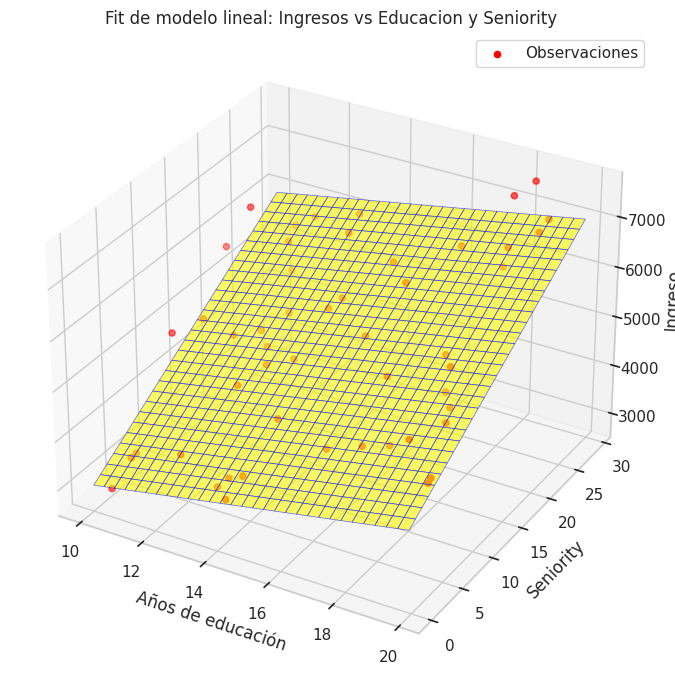

In [ ]:

# Creamos dataset sintético de ingresos (tomado de Introduction to Statistical Learning)
np.random.seed(1)
n = 50
education = np.random.uniform(10, 20, n)      # Educacion
seniority = np.random.uniform(0, 30, n)       # Seniority
income = 1000 + 150 * education + 120 * seniority + np.random.normal(0, 1000, n)

# Dataframe
df = pd.DataFrame({
    'Education': education,
    'Seniority': seniority,
    'Income': income
})

# Modelo lineal
X = df[['Education', 'Seniority']]
y = df['Income']
model = LinearRegression().fit(X, y)

# Prediccion en grid
edu_range = np.linspace(df['Education'].min(), df['Education'].max(), 30)
sen_range = np.linspace(df['Seniority'].min(), df['Seniority'].max(), 30)
edu_grid, sen_grid = np.meshgrid(edu_range, sen_range)
income_pred = model.predict(np.c_[edu_grid.ravel(), sen_grid.ravel()]).reshape(edu_grid.shape)

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Education'], df['Seniority'], df['Income'], color='red', label='Observaciones')
ax.plot_surface(edu_grid, sen_grid, income_pred, color='yellow', alpha=0.6, edgecolor='blue', linewidth=0.5)

ax.set_xlabel('Años de educación')
ax.set_ylabel('Seniority')
ax.set_zlabel('Ingreso')
plt.title('Fit de modelo lineal: Ingresos vs Educacion y Seniority')
plt.legend()
plt.tight_layout()
plt.show()



El ajuste lineal no es del todo correcto: la verdadera función $f$ tiene cierta **curvatura** que no se capta en el ajuste lineal. Sin embargo, el ajuste lineal parece hacer un trabajo razonable al capturar la relación positiva entre los años de educación y el ingreso, así como la relación ligeramente más positiva entre seniority e ingreso.

**VENTAJA**: Suponer una forma paramétrica para $f$ simplifica el problema de estimar $f$, porque en general es mucho más fácil estimar un conjunto de parámetros, como $\beta_0, \beta_1, \dots, \beta_p$ en el modelo lineal que ajustar una funcion arbitraria $f$

**DESVENTAJA**: el modelo que elijamos usualmente no coincidirá con la verdadera forma desconocida de $f$. Si el modelo elegido está muy alejado del $f$ real, entonces nuestra estimación será deficiente. Podemos intentar abordar este problema eligiendo modelos más **flexibles**, que puedan ajustarse a muchas formas funcionales posibles para $f$. Modelos más flexibles implican estimar mayor cantidad de parámetros. Esto acarrea complejidad y podemos caer en un problema de sobreajuste (que sería algo así como capturar el ruido de los datos). Lo veremos más adelante en profundidad.



### Modelos no paramétricos


- Los métodos **no paramétricos** no hacen suposiciones explícitas sobre la forma funcional de $f$.
- Buscan una estimación de $f$ que se acerque lo más posible a los puntos de datos sin ser demasiado irregular u ondulada (pueden tener una ventaja visible frente al ajuste al training set y modelos paramétricos).
- Tienen como principal desventaja que se requiere una gran cantidad de observaciones para obtener una estimación precisa de $f$
- El ajuste exagerado que veremos debajo parece ser mucho más variable que la verdadera función $f$. Este es un ejemplo de **sobreajuste** (*overfitting*). Esto es no deseado ya que no dará estimaciones precisas del ingreso en observaciones que no formen parte del conjunto de datos original.



<ipython-input-8-902ea5d880db>:2: UserWarning:


The required storage space exceeds the available storage space: nxest
or nyest too small, or s too small.
The weighted least-squares spline corresponds to the current set of
knots.



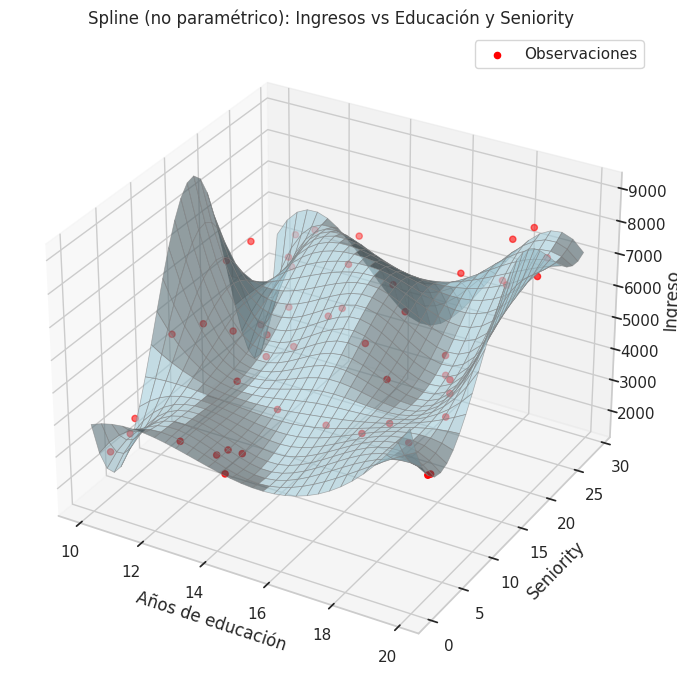

In [ ]:
# Modelo spline no paramétrico
spline_model = SmoothBivariateSpline(df['Education'], df['Seniority'], df['Income'], s=5000)

# Predicción sobre la grilla
income_pred_spline = spline_model.ev(edu_grid.ravel(), sen_grid.ravel()).reshape(edu_grid.shape)

# Plot 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Education'], df['Seniority'], df['Income'], color='red', label='Observaciones')
ax.plot_surface(edu_grid, sen_grid, income_pred_spline, color='lightblue', alpha=0.6, edgecolor='gray', linewidth=0.5)

ax.set_xlabel('Años de educación')
ax.set_ylabel('Seniority')
ax.set_zlabel('Ingreso')
plt.title('Spline (no paramétrico): Ingresos vs Educación y Seniority')
plt.legend()
plt.tight_layout()
plt.show()

## Trade-Off entre performance e interpretabilidad

Cuando trabajamos con datos y queremos construir un modelo que relacione una variable de interés $Y$ con un conjunto de predictores $X_1, X_2, ..., X_P$, tenemos muchas métodos disponibles. **Algunos son más restrictivos,** lo que significa que solo pueden ajustar formas relativamente simples. **Otros, en cambio, son más flexibles** y pueden adaptarse a relaciones mucho más complejas.

Por ejemplo, la regresión lineal es relativamente inflexible: solo puede capturar relaciones lineales entre las variables. En cambio, técnicas como los splines son considerablemente más flexibles porque pueden adaptarse a una gama mucho más amplia de formas funcionales.

Entonces, surge la siguiente pregunta: **¿por qué usar un modelo más restrictivo si podemos elegir uno más flexible?**
La respuesta depende de qué estamos buscando. Si nuestro objetivo principal es entender cómo cada predictor influye sobre la respuesta, conviene usar **métodos simples**, porque **son mucho más interpretables**. Por ejemplo, en una regresión lineal podemos leer directamente cómo cambia $Y$ si aumentamos $X_1$ o $X_2$
 , algo que resulta mucho más complicado en modelos muy flexibles.

En la siguiente figura se muestra  este balance entre flexibilidad e interpretabilidad:



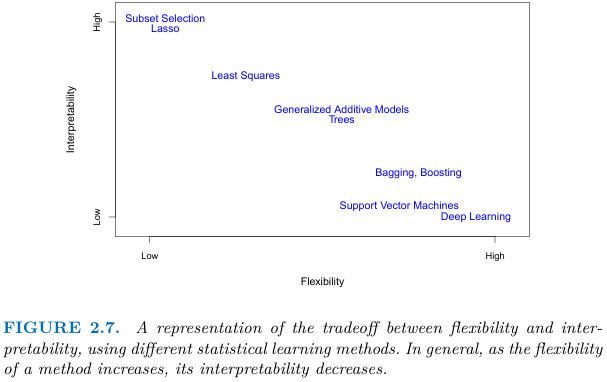


Fuente: James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An introduction to statistical learning* (Vol. 112, No. 1). Springer.

* La regresión lineal es inflexible, pero fácil de interpretar.

* El método de Lasso, una variante de la regresión lineal que penaliza los coeficientes y puede llevar algunos a ser exactamente cero, es aún más restrictivo. Esto no solo reduce la flexibilidad sino que también mejora la interpretabilidad, ya que en el modelo final la variable respuesta queda asociada únicamente a un pequeño subconjunto de variables predictoras relevantes.

* Por otro lado, métodos como bagging, boosting o redes neuronales son muy flexibles, pero son más difíciles de interpretar.

* **Entonces, cuando el objetivo es la inferencia, los métodos simples y relativamente inflexibles son más adecuados.**

* En cambio, **si en lugar de explicar queremos simplemente predecir, la interpretabilidad no importa tanto.** Por ejemplo, si queremos construir un modelo para predecir el precio de una acción, lo que nos interesa es que la predicción sea lo más acertada posible, y no necesariamente entender los mecanismos detrás de la misma.

* **Aunque podría pensarse que un modelo más flexible siempre predice mejor, esto no es necesariamente así.** Modelos muy flexibles corren un mayor riesgo de sobreajustarse al conjunto de entrenamiento (conceptos que vamos a profundizar más adelante), lo que puede afectar su desempeño. Por eso, a es posible que métodos menos flexibles logren predicciones más precisas.


## Supervisado vs no supervisado

La mayoría de los problemas de aprendizaje estadístico se encuadran en una de las siguientes dos categorías: aprendizaje supervisado o aprendizaje no supervisado.

En el caso de **aprendizaje supervisado**, para cada observación de las variables predictoras $x_i$ con $i=1, …, x_n$, hay una respuesta asociada $y_i$. Se busca ajustar un **modelo que relacione la respuesta a los predictores**, con el objetivo de predecir de forma precisa la respuesta para futuras observaciones (**predicción**) o para un mejor entendimiento de la relación entre la respuesta y los predictores (**inferencia**).


En cambio, el **aprendizaje no supervisado** se refiere a una situación algo más desafiante, en la cual, para cada observación $i=1,...,n$, solo se dispone de un vector de variables predictoras $x_i$, sin una respuesta asociada $y_i$. Dado que no hay una variable que se quiera predecir, no es posible, por ejemplo, ajustar un modelo de regresión lineal.

Entonces, ¿qué tipo de análisis estadístico es posible en este contexto? El foco suele estar en **descubrir relaciones entre las variables o entre las observaciones**. Una herramienta común del aprendizaje no supervisado es el ***clustering*** (agrupamiento). El objetivo del análisis de clústeres es determinar, a partir de los datos $x_1, ..., x_n$, si las observaciones se agrupan de manera natural en subconjuntos bien diferenciados.
Por ejemplo, en un estudio de segmentación de mercado, podríamos observar múltiples variables para potenciales clientes, como el código postal, el ingreso familiar y los hábitos de compra. Es razonable suponer que los clientes podrían pertenecer a distintos grupos, como grandes compradores y compradores ocasionales.

En la siguiente figura se ilustra un problema de agrupamiento: se grafican 150 observaciones en función de dos variables, $X_1$ y $X_2$. Cada punto pertenece a uno de tres grupos distintos. A fines ilustrativos, los miembros de cada grupo se representan con diferentes colores y símbolos. No obstante, en la práctica, estos grupos son desconocidos, y el objetivo es inferir a qué grupo pertenece cada observación. En el panel izquierdo, la tarea es relativamente sencilla, ya que los grupos están bien separados. En cambio, en el panel derecho, la superposición entre grupos dificulta el problema, y no puede esperarse que un método de clustering asigne correctamente todas las observaciones superpuestas.

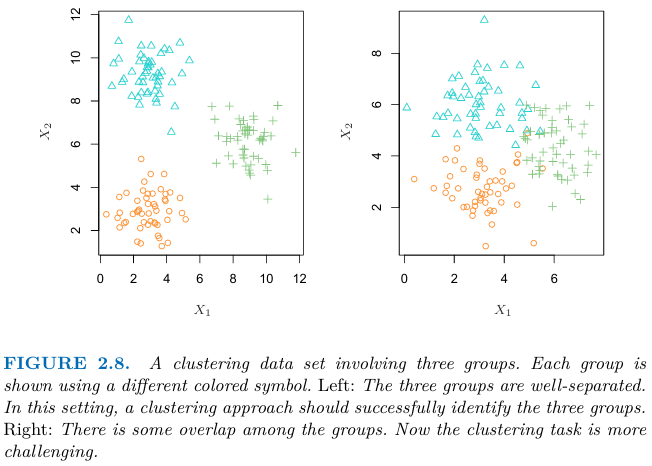

Fuente: James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An introduction to statistical learning* (Vol. 112, No. 1). Springer.

En el ejemplo mostrado hay solo dos variables, por lo que resulta fácil inspeccionar visualmente los gráficos de dispersión para identificar agrupamientos. Sin embargo, en la práctica es común trabajar con conjuntos de datos que contienen **muchas más variables**. En esos casos, la visualización directa no es factible. Por ejemplo, con $p$ variables se pueden generar $p(p-1)/2$ gráficos de dispersión distintos, y **una inspección visual deja de ser viable**. Por esta razón, los métodos automáticos de clustering adquieren especial relevancia.

Muchos problemas encajan de forma natural dentro de los paradigmas supervisado o no supervisado. No obstante, en algunos casos, esta distinción no es tan clara. Por ejemplo, supongamos que tenemos un conjunto de $n$ observaciones, pero solo para $m<n$ de ellas contamos con predictores y respuesta, mientras que para las $n−m$ restantes solo tenemos los predictores. Esta situación puede surgir si las variables predictoras son relativamente fáciles de medir, mientras que obtener las respuestas asociadas resulta costoso o difícil. A este tipo de problema se lo denomina aprendizaje **semi-supervisado**. En estos casos, se busca aplicar métodos que aprovechen tanto las $m$ observaciones con respuesta como las $n−m$ sin ella.

## Regresión vs Clasificación

Como vimos anteriormente, las variables pueden clasificarse en dos grandes tipos: cuantitativas o categóricas. Las variables cuantitativas toman valores numéricos, mientras que las categóricas representan clases o categorías.
Cuando la **variable respuesta** es cuantitativa, nos encontramos frente a un problema de **regresión**; en cambio, si la respuesta es categórica, hablamos de un problema de **clasificación**.

Algunos métodos de aprendizaje pueden utilizarse tanto en problemas de regresión como de clasificación, mientras que otros están diseñados específicamente para uno de los dos tipos.
Respecto a las variables predictoras, la mayoría de los métodos pueden aplicarse sin importar si éstas son cuantitativas o categóricas, siempre que nos aseguremos de codificar adecuadamente los predictores categóricos.

## Evaluación de la performance de un modelo

En un conjunto de datos determinado, un método en particular puede ofrecer mejores resultados, mientras que en otro conjunto similar, pero diferente, otro método podría tener mejor desempeño. Por eso, una tarea fundamental consiste en **decidir qué método produce los mejores resultados** para un conjunto de datos dado.
Seleccionar el enfoque más adecuado suele ser uno de los aspectos más desafiantes a la hora de aplicar el aprendizaje estadístico en la práctica.

### Midiendo la bondad de ajuste

Para evaluar la performance de un método de aprendizaje estadístico aplicado a un determinado conjunto de datos, **necesitamos una forma de medir qué tan bien sus predicciones se ajustan a los valores observados**. En otras palabras, queremos cuantificar cuán cerca está la respuesta predicha del valor real para cada observación. En los problemas de regresión, uno de los indicadores más utilizados es el **error cuadrático medio** (ECM o MSE, por sus siglas en inglés):

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{f}(x_i))^2
$$

donde $\hat{f}(x_i)$ es la predicción de la observación $i$ dada por $\hat{f}$.

El MSE será bajo si las predicciones están muy próximas a los valores reales, y alto si para algunas observaciones existe una gran diferencia entre lo predicho y lo observado.

#### $MSE_{train}$ vs. $MSE_{test}$
Normalmente, el MSE se calcula sobre los datos de entrenamiento, es decir, los mismos datos que se usaron para ajustar el modelo. En ese caso, deberíamos llamarlo MSE de entrenamiento o $MSE_{train}$. Sin embargo, **no nos interesa tanto qué tan bien funciona el modelo en esos datos, sino qué tan preciso es al hacer predicciones sobre datos nuevos**, que no vio previamente durante el entrenamiento.

¿Por qué esto es importante? Supongamos que queremos desarrollar un algoritmo para predecir el precio de una acción en función de su rendimiento pasado. Podemos entrenar el modelo con datos de los últimos seis meses, pero no nos interesa si predice bien el precio de la semana pasada. Lo que realmente nos importa es si puede predecir correctamente el precio de mañana o del mes que viene. De forma similar, pensemos en un conjunto de datos médicos, con información como peso, presión arterial, altura, edad e historial familiar, junto con la presencia o no de diabetes. Podemos entrenar un modelo para estimar el riesgo de desarrollar la enfermedad, pero lo valioso será su capacidad para hacer buenas predicciones sobre pacientes futuros, no sobre aquellos que ya conocemos.

De forma matemática, supongamos que ajustamos nuestro modelo a nuestras observaciones de entrenamiento ${(x_1, y_1), (x_2, y_2), …, (x_n, y_n)}$, y obtenemos la estimación de $\hat{f}$. Podemos entonces computar $\hat{f}(x_1), \hat{f}(x_2), ..., \hat{f}(x_n)$.  Si estos son aproximadamente iguales a $y_1, y_2, …, y_n$, entonces el $MSE_{train}$ es bajo. De todas maneras, no estamos interesados en si $\hat{f}(x_i) = y_i$; en cambio, queremos saber si $\hat{f}(x_0)$ es aproximadamente igual a $y_0$, donde $(x_0, y_0)$ es una observación del conjunto de test que no fue usada para el entrenamiento y por lo tanto no fue vista por el modelo previamente. En definitiva, **queremos elegir el método que da el $MSE_{test}$ más bajo**, en lugar del $MSE_{train}$ más bajo.

Entonces, ¿cómo podemos seleccionar un método que minimice el $MSE_{test}$?

* En algunos casos, contamos con un conjunto de datos de test separado, es decir, observaciones que no se usaron para entrenar el modelo. En ese caso, podemos simplemente aplicar el modelo sobre ese conjunto y elegir el que arroje el menor $MSE_{test}$.
* Pero, ¿qué pasa si no tenemos datos de prueba? Podríamos pensar en elegir el modelo que minimice el $MSE_{train}$, suponiendo que ambos $MSE$ están relacionados. Sin embargo, esto presenta un problema importante: **no hay garantía de que el modelo con el menor error en entrenamiento también tenga el menor error en test.**



#### Relación entre $MSE_{train}$ y $MSE_{test}$. Overfitting

La siguiente figura ilustra este fenómeno con un ejemplo simple.

* En el panel de la izquierda, se generaron observaciones a partir de $Y = f(x) + ϵ$, donde la $f$ verdadera está dada por la curva negra.

* Las curvas naranja, azul y verde ilustran tres posibles estimaciones de $f$ obtenidas usando métodos con niveles crecientes de flexibilidad. La línea naranja es el ajuste por regresión linear, el cual es relativamente inflexible. Las curvas azul y verde se generaron usando splines con diferentes niveles de suavizado.

* A medida que el nivel de flexibilidad aumenta, las curvas se ajustan de forma más cercana a los datos observados. **La curva verde, la más flexible, se ajusta casi perfectamente a los datos, pero se aleja bastante de la función $f$ verdadera**, con muchas ondulaciones innecesarias.

* Variando el nivel de flexibilidad del ajuste podemos producir muchas estimaciones diferentes para este conjunto de datos.

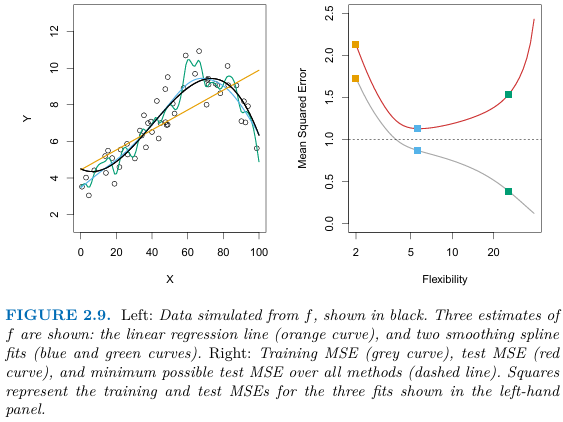

En el panel derecho, se muestra cómo varía el $MSE_{train}$ en función de la flexibilidad del modelo (o grados de libertad). Esta medida indica cuán complejo o adaptable es un modelo. Los cuadrados naranja, azul y verde, representan los errores de las tres curvas del panel izquierdo.

Como conocemos la función verdadera $f$ podemos generar un conjunto de test tan grande como queramos con datos nuevos. En la práctica esto no es posible porque $f$ es desconocida.

* En el gráfico, el $MSE_{test}$ aparece en rojo. Se observa que, al igual que el $MSE_{train}$, **disminuye al principio cuando la flexibilidad aumenta**, pero el $MSE_{test}$ luego se estabiliza y comienza a crecer.

* Tanto la curva naranja como la verde tienen errores altos en test. En cambio, **la curva azul logra el menor $MSE_{test}$**, lo cual es consistente con lo observado en el panel izquierdo.

* La línea punteada horizontal indica el **error irreducible** que se corresponde con el **MSE de test más bajo alcanzable.** Por lo tanto, la spline azul está cerca del ajuste óptimo.

En el panel de la derecha, vemos también que:
* a medida que la flexibilidad del modelo aumenta, hay un **descenso monótono en el $MSE_{train}$ y una forma de U en el $MSE_{test}$**. Esta es una propiedad fundamental del aprendizaje estadístico que se mantiene sin importar el *dataset* o el método usado.

* Cuando un modelo dado presenta un **$MSE_{train}$ bajo pero un $MSE_{test}$ alto**, decimos que esta sobreajustandose a los datos (**overfitting**), **ha aprendido demasiado bien los detalles del conjunto de entrenamiento, incluyendo el ruido aleatorio, y no generaliza bien a nuevos datos.** En estos casos, el modelo ha encontrado patrones que solo existen en el conjunto de entrenamiento, pero no se repiten en datos nuevos.

Por otra parte, incluso sin sobreajuste, es normal que el $MSE_{train}$ sea menor que el $MSE_{test}$, ya que la mayoría de los métodos están diseñados para ajustarse lo mejor posible a los datos de entrenamiento. Hablamos de sobreajuste (overfitting) cuando un modelo más simple hubiera tenido un mejor desempeño en test.

La siguiente figura da otro ejemplo en el cual la $f$ verdadera es aproximadamente lineal. Nuevamente observamos que el $MSE_{train}$ disminuye monótonamente a medida que la flexibilidad crece, y que hay una forma de U en el $MSE_{test}$. De todas maneras, como **la $f$ verdadera es casi lineal**, el $MSE_{test}$ apenas decrece antes de incrementar de nuevo, por lo que el ajuste naranja es sustancialmente mejor que la curva verde.

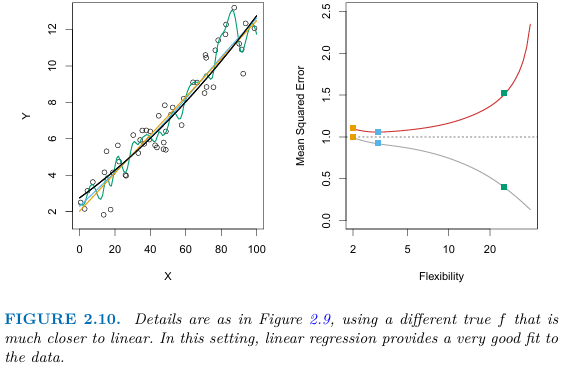

Por último, la siguiente figura presenta un ejemplo en el cual **$f$ es fuertemente no lineal**. Las curvas de error para entrenamiento y test muestran el mismo patrón general, pero ahora hay una rápida disminución en las dos curvas antes de que el $MSE$ empieza a crecer lentamente.

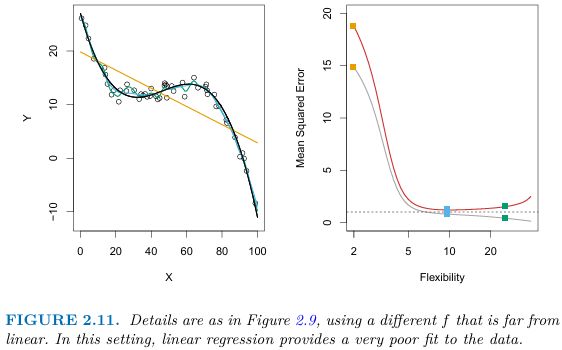

En la práctica, en general podemos computar el $MSE_{train}$ relativamente fácil, pero estimar el $MSE_{test}$ es considerablemente más difícil porque no siempre tenemos datos de test disponibles. Como se ve en los tres ejemplos presentados, **el nivel de flexibilidad correspondiente con el modelo que minimiza el $MSE_{test}$ puede variar considerablemente según el conjunto de datos.** Una técnica clave para poder estimar ese valor óptimo es la **validación cruzada (cross-validation)**, que permite estimar el $MSE_{test}$ usando solo datos de entrenamiento.  

### Trade-off sesgo-varianza

### Composición del error
La forma de U que se observa en la curva de error en test es el resultado de dos propiedades de los métodos de aprendizaje que compiten entre sí.

Se puede demostrar que el valor esperado de $MSE_{test}$ para un determinado valor $x_0$, puede descomponerse en la suma de tres factores: la variancia de $\hat{f}(x_0)$, el cuadrado del *bias* o sesgo de $\hat{f}(x_0)$ y la varianza del término de error $\epsilon$. Esto es

\\
$$
E(y_0 - \hat{f}(x_0))^2 = Var(\hat{f}(x_0)) + [Bias(\hat{f}(x_0))]^2+Var(\epsilon)
$$

\\

Acá la notación $ E(y_0 - \hat{f}(x_0))^2$ define el valor esperado de $MSE_{test}$ en $x_0$, y se refiere al  $MSE_{test}$ promedio que se obtendría si estimados repetidamente $f$ usando un número grande de conjuntos de entrenamiento, y testeamos cada uno en $x_0$. El $MSE_{test}$ general esperado se puede computar haciendo el promedio de $E(y_0 - \hat{f}(x_0))^2$ a través de todo los posibles valores de $x_0$ en el conjunto de test.


Esta ecuación nos dice que, con el objetivo de minimizar el error esperado en test, **necesitamos seleccionar un método que simultáneamente consiga baja varianza y bajo *bias***. Los dos primeros términos no pueden ser negativos, por lo que el MSE nunca va a poder ser menor que $Var(\epsilon)$, el error irreducible que vimos antes.

#### ¿A qué nos referimos con la ***varianza*** y el ***bias*** de un método?

* **Varianza**

La varianza se refiere a **cuánto puede variar $\hat{f}$ si la estimamos usando diferentes conjuntos de entrenamiento**. Dado que el conjunto de entrenamiento se usa para ajustar el modelo, diferentes *datasets* van a resultar en diferentes $\hat{f}$. Pero idealmente la estimación de $f$ no debería variar demasiado entre distintos datasets.

Si el método tiene **varianza elevada**, **pequeños cambios en los datos de entrenamiento pueden resultar en grandes cambios de $\hat{f}$**. En general, modelos más flexibles y complejos poseen mayor varianza.


Veamos las curvas verde y naranja de un ejemplo anterior.

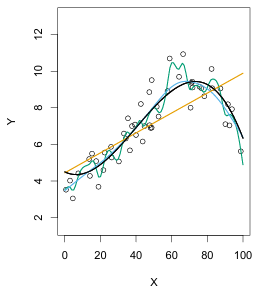

* La **curva verde** se sigue a las observaciones muy de cerca. Tiene **varianza alta** porque si cambiamos cualquiera de estos puntos causaría que la estimación de $\hat{f}$ cambie considerablemente.

* En cambio, la **naranja** es relativamente inflexible y tiene **baja varianza**, porque si movemos una única observación probablemente ocurra solo un pequeño cambio en la posición de la línea.


- ***Bias*** (o sesgo)

El bias (o sesgo) es el error que se introduce al representar un problema complejo del mundo real mediante un **modelo simplificado**.

Volviendo a los ejemplos anteriores:

  • si la verdadera $f$ es fuertemente no lineal, no importa cuántos datos para el entrenamiento tengamos disponibles, no será posible obtener una estimación precisa usando regresión lineal. En otras palabras, para este ejemplo, la regresión lineal tiene un *bias* elevado.

  • En cambio, si la $f$ es casi lineal y tenemos suficientes datos, la regresión lineal nos va a poder dar una estimación suficientemente precisa. En general, modelo más flexibles y complejos resultan en *bias* menores.

### Impacto de trade-off sesgo-varianza en el MSE

• Como regla general, a medida que usamos modelos más flexibles, la varianza aumenta y el bias disminuye.

• La tasa relativa de cambio de estas dos cantidades determina si el $MSE_{test}$ aumenta o disminuye.

• Inicialmente, a medida que aumentamos la flexibilidad, el sesgo tiende a disminuir más rápido que el aumento de la varianza. En consecuencia, el $MSE_{test}$ esperado disminuye.

• Sin embargo, en algún momento, aumentar la flexibilidad tiene poco impacto en el sesgo, pero comienza a aumentar significativamente la varianza. Cuando esto sucede, el $MSE_{test}$ aumenta.

Esto explica la forma de U que veníamos viendo en el error en test en los ejemplos anteriores.

Los tres gráficos de la siguiente figura muestran los distintos términos de la ecuación del error para los ejemplos que vimos anteriormente. La curva celeste representa el cuadrado del *bias* y la curva naranja corresponde a la varianza. La línea horizontal representa el error irreducible. Por último, la curva roja, corresponde al $MSE_{test}$ (suma de las otras tres curvas).

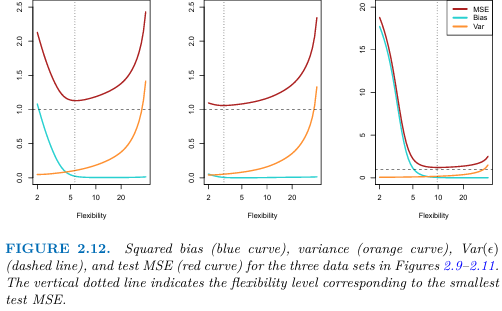

Vemos que:
* En los tres casos la varianza crece y el bias disminuye a medida que la flexibilidad aumenta.
* El nivel de flexibilidad óptimo, que corresponde al $MSE_{test}$ mínimo, difiere considerablemente en los tres ejemplos.


#### Resumen del trade-off sesgo-varianza
Para lograr un buena performance en el conjunto de test, es necesario que tanto la varianza como el bias al cuadrado sean bajos. Este equilibrio se conoce como trade-off entre sesgo y varianza. Es relativamente fácil construir un modelo con un sesgo muy bajo pero una varianza alta (por ejemplo, ajustando una curva que pase exactamente por cada observación del conjunto de entrenamiento), o uno con varianza baja pero sesgo elevado (como una línea horizontal que ignore las tendencias de los datos). **El verdadero desafío consiste en encontrar un modelo que logre minimizar ambos componentes simultáneamente.**


### Problema de clasificación

Hasta ahora discutimos la precisión de un modelo centrándonos en un problema de regresión. Pero muchos de los conceptos que fuimos desarrollando, como el trade-off sesgo varianza, se mantienen cuando pasamos a los problemas de clasificación.
El enfoque más sencillo para cuantificar la precisión de nuestra estimación $\hat{f}$ es la **tasa de error**, es decir la proporción de equivocaciones que cometemos si aplicamos nuestra estimación $\hat{f}$:

$$
\frac{1}{n}\sum_{i=1}^{n}I(y_i\neq \hat{y_i})
$$

Donde
* $\hat{y_i}$ es la clase predicha para la observación $i$ésima usando $\hat{f}$.
* $I(y_i\neq \hat{y_i})$ es un indicador que es igual a 1 cuando $y_i\neq \hat{y_i}$ y 0 si $y_i = \hat{y_i}$·






#### El clasificador de Bayes
Se puede demostrar que la tasa de error se puede minimizar, en promedio, usando un clasificador muy simple que **asigna a cada observación la clase más probable** dados los valores de sus variables predictoras.

En otras palabras, debemos simplemente asignar a cada dato del conjunto de test, **la clase $j$ para la cual la probabilidad condicional $Pr(Y=j|X=x_0)$ es máxima**, donde $x_0$ es el vector de variables predictoras.

En un ejemplo de dos clases, el clasificador de Bayes predice la clase 1 si $Pr(Y=1/X=x_0) > 0.5$, o clase 2 en en caso contrario.

En la siguiente figura se da un ejemplo usando un dataset de dos dimensiones generado sintéticamente.

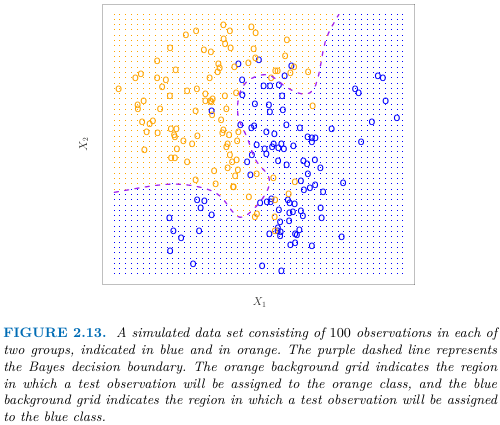

* Los círculos naranjas y azules corresponden a los datos de entrenamiento que pertenecen a dos clases distintas.
* Para cada valor de $X_1$ y $X_2$, hay diferente probabilidad de que la respuesta sea naranja o azul. Dado que es un dataset generado sintéticamente, sabemos como fueron generados los datos y podemos calcular las probabilidades condicionales de cada valor de $X_1$ y $X_2$.

* La región sombreada en naranja muestra los puntos para los cuales la probabilidad $Pr(Y=naranja | X)$ es mayor a 50%, mientras que la región azul representa las combinaciones de $X_1$ y $X_2$ donde esa probabilidad está por debajo de 50%.

* La línea punteada representa los puntos donde la probabilidad condicional es exactamente igual a 50%, y se denomina la **frontera de decisión de Bayes**. La clasificación de este método va a estar determinada por esta frontera, las observaciones que caen en el lado naranja van a ser clasificadas como naranja, y de forma similar con el lado azul.

* El clasificador de Bayes **produce la menor tasa de error en test alcanzable**, llamada **tasa de error de Bayes**. Dado que el clasificador de Bayes va a elegir siempre la clase para la cual la probabilidad condicional se maximiza, la tasa de error en el punto $X = x_0$, va a ser:

$$
1 – max_j Pr(Y=j | X = x_0)
$$

* La tasa global de error de Bayes está dada por

$$
1 – E(max_j Pr(Y=j|X))
$$


donde la esperanza promedia la probabilidad sobre todos los posibles valores de $X$.
Para el dataset del ejemplo, la tasa de error de Bayes es 0.13. Es mayor que cero dado que las clases se superponen en la población real. **La tasa de error de Bayes es análoga al error irreducible que hablábamos anteriormente.**


#### K-Nearest Neighbors (KNN)


* En problemas reales, nosotros no conocemos la distribución de probabilidad condicional de Y dado X, entonces aplicar el clasificador de Bayes resulta imposible. Entonces, el clasificador de Bayes sirve como un estándar inalcanzable contra el cual comparar otros métodos.

* Muchos enfoques intentan **estimar la distribución condicional de Y dado X**, y luego clasificar una determinada observación con la categoría con la mayor probabilidad estimada. Uno de esos métodos es el clasificador KNN.

* Dado un entero positivo K, y una observación $x_0$ de test, el clasificador KNN primero identifica los **K puntos en el conjunto de entrenamiento que se encuentran más cercanos a $x_0$**, representados por $\mathbb{N}_0$. Luego estima la probabilidad condicional de clase $j$ como la fracción de los puntos en $\mathbb{N}_0$ cuya variable respuesta sea igual a $j$.


$$
Pr(Y=j|X=x_0) =\frac{1}{K}\sum_{i \in \mathbb{N}_0} I(y_i = j)
$$

* Finalmente, el método KNN clasifica la observación $x_0$ como la clase $j$ que maximiza esa probabilidad estimada.


La siguiente figura da un ejemplo ilustrativo de este método.

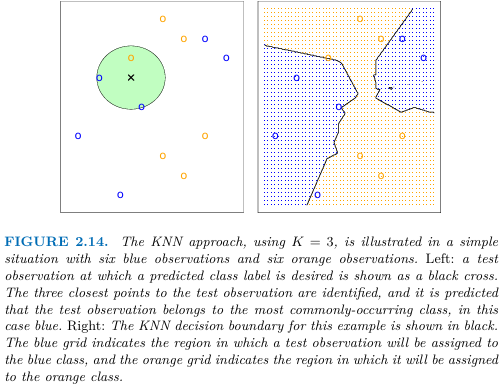

* En el panel izquierdo se encuentra graficado un pequeño conjunto de entrenamiento que consiste en 6 observaciones naranjas y 6 azules. **Nuestro objetivo es realizar la predicción para el punto indicado con una cruz negra.** Supongamos que elegimos K=3. Entonces el algoritmo primero va a identificar las tres observaciones más cercanas a la cruz. Este vecindario se muestra con un círculo. Consiste de dos puntos azules y uno naranja, resultando en las probabilidades estimadas de **2/3 para la clase azul y 1/3 para la clase naranja**. Entonces KNN va a predecir que la cruz negra pertenece a la categoría azul.

* En el panel derecho se aplicó KNN con K=3 a todas las posibles combinaciones de $X_1$ y $X_2$, y se graficó la correspondiente frontera de decisión.

Más allá del hecho de que es un método muy simple, con KNN se pueden llegar a obtener clasificadores que se acercan mucho al caso óptimo del clasificador de Bayes. La siguiente figura muestra la frontera de decisión aplicando KNN con K=10, aplicado al dataset que vimos de ejemplo para el clasificador de Bayes.

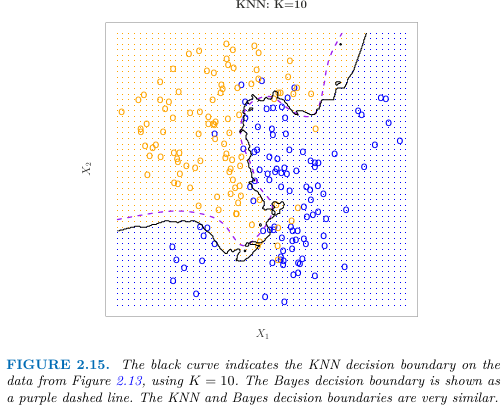

Se puede ver que el método KNN, aun sin conocer la verdadera distribución de probabilidad condicional, presenta una frontera de decisión muy cercana a la del clasificador de Bayes.

La tasa de error en test para KNN es 0.1363, muy cercana a la tasa de error de Bayes de 0.1304.

La selección de K tiene un gran efecto en la clasificación. En la siguiente figura vemos las fronteras de decisión con K=1 y K=100.

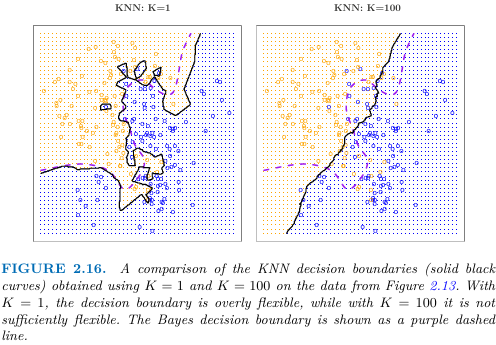

* Cuando K=1 la frontera es demasiado flexible y encuentra patrones que no se condicen con la frontera de Bayes. Tenemos un clasificador con bajo bias pero mucha varianza.
* A medida que K crece, produce una frontera de decisión que es casi lineal. Esto corresponde con un clasificador de baja varianza, pero alto bias.
* Ninguno de los dos clasificadores (con K=1 y K=100) dan buenas predicciones, tienen tasas de error de 0.1695 y 0.1925 respectivamente.
* **Tanto en la regresión como en la clasificación, elegir el nivel correcto de flexibilidad es fundamental para el éxito de cualquier método de aprendizaje estadístico.**


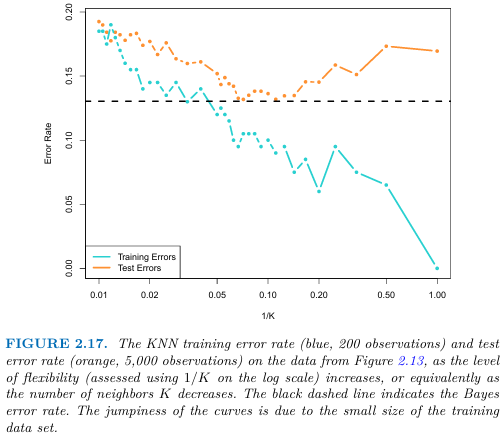

## Librerías nuevas

En lo que resta de la materia para aprendizaje supervisado y no supervisado haremos uso de las siguientes librerías:

[scikit-learn](https://scikit-learn.org/stable/index.html)